# SBI with an Attentive Neural Process (ANP) Emulator

End-to-end pipeline: **ANP Emulator → Observational Data → Forward Model → SBI (NPE)**

This notebook constrains 35 cosmological + astrophysical CAMELS parameters from ICM
profiles using an ANP emulator instead of the standard feedforward neural network.

**Key advantages of the ANP over a standard NN emulator:**
- Calibrated heteroscedastic uncertainty (aleatoric + epistemic) at every prediction
- Mass-, radius-, and parameter-dependent scatter — no separate scatter table needed
- Trained on all 4 channels (temperature, pressure, gas_density, metallicity) jointly
- Arbitrary radial resolution (not locked to a fixed grid)

---
## 0. Setup & Configuration

In [ ]:
import sys
from pathlib import Path

# Allow imports from the repo root
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import torch
import json, os, time, pickle
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({
    "font.size": 11,
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# ── Paths ──
FIT_DATA_DIR = Path("/mnt/home/mlee1/fit_data")
DATA_DIR = FIT_DATA_DIR / "processed_data"
ANP_CKPT = Path("..") / "anp_training_runs" / "anp_all_profiles_20260325_175639" / "best_model.pt"
RESULTS_DIR = Path("../sbi_results")
RESULTS_DIR.mkdir(exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Quick test mode ──
# Set False for production runs (200k sims). True for fast iteratioThe QUICK_TEST = False

# ── Pipeline settings ──
if QUICK_TEST:
    N_SIMS = 10_000
    MAX_EPOCHS = 5
    N_ANP_SAMPLES = 3
    N_POSTERIOR = 10_000
    print("⚡ QUICK_TEST mode: 10k sims, 3 ANP samples")
else:
    N_SIMS = 200_000
    MAX_EPOCHS = 200
    N_ANP_SAMPLES = 10
    N_POSTERIOR = 50_000

OBS_LOGM_MAX = 14.9      # upper mass cut for observations

# ── Fix cosmological parameters? ──
# When True, cosmo params are held at Planck fiducial values and only
# the 30 astrophysical parameters are explored by the NPE.
FIX_COSMO = True

COSMO_PARAMS = {"Omega0", "sigma8", "OmegaBaryon", "HubbleParam", "n_s"}

# Physical constants for gas_density → n_e conversion
MU_E = 1.176              # mean molecular weight per electron (fully ionized primordial+metals)
M_PROTON = 1.6726e-24     # proton mass in grams
LOG10_MU_E_MP = np.log10(MU_E * M_PROTON)  # ≈ -23.706

Device: cuda


---
## 1. Load the ANP Emulator

The ANP predicts 4 profile channels (temperature, pressure, gas_density, metallicity)
at arbitrary `r/R500` ratios. It provides calibrated uncertainty estimates that we use
as the intrinsic scatter model.

In [4]:
from anp_emulator import Emulator

emu = Emulator.from_checkpoint(str(ANP_CKPT.resolve()), device=str(DEVICE))

print(f"ANP checkpoint: {ANP_CKPT.name}")
print(f"Target channels: {emu.target_names}")
print(f"Theta dim: {emu.theta_dim}")
print(f"Snapnum: {emu.snapnums} (z=0)")

ANP checkpoint: best_model.pt
Target channels: ['gas_density', 'temperature', 'pressure', 'metallicity']
Theta dim: 35
Snapnum: [90] (z=0)


### 1.1 Quick Emulator Validation

Predict profiles at fiducial parameters for several masses to sanity-check.

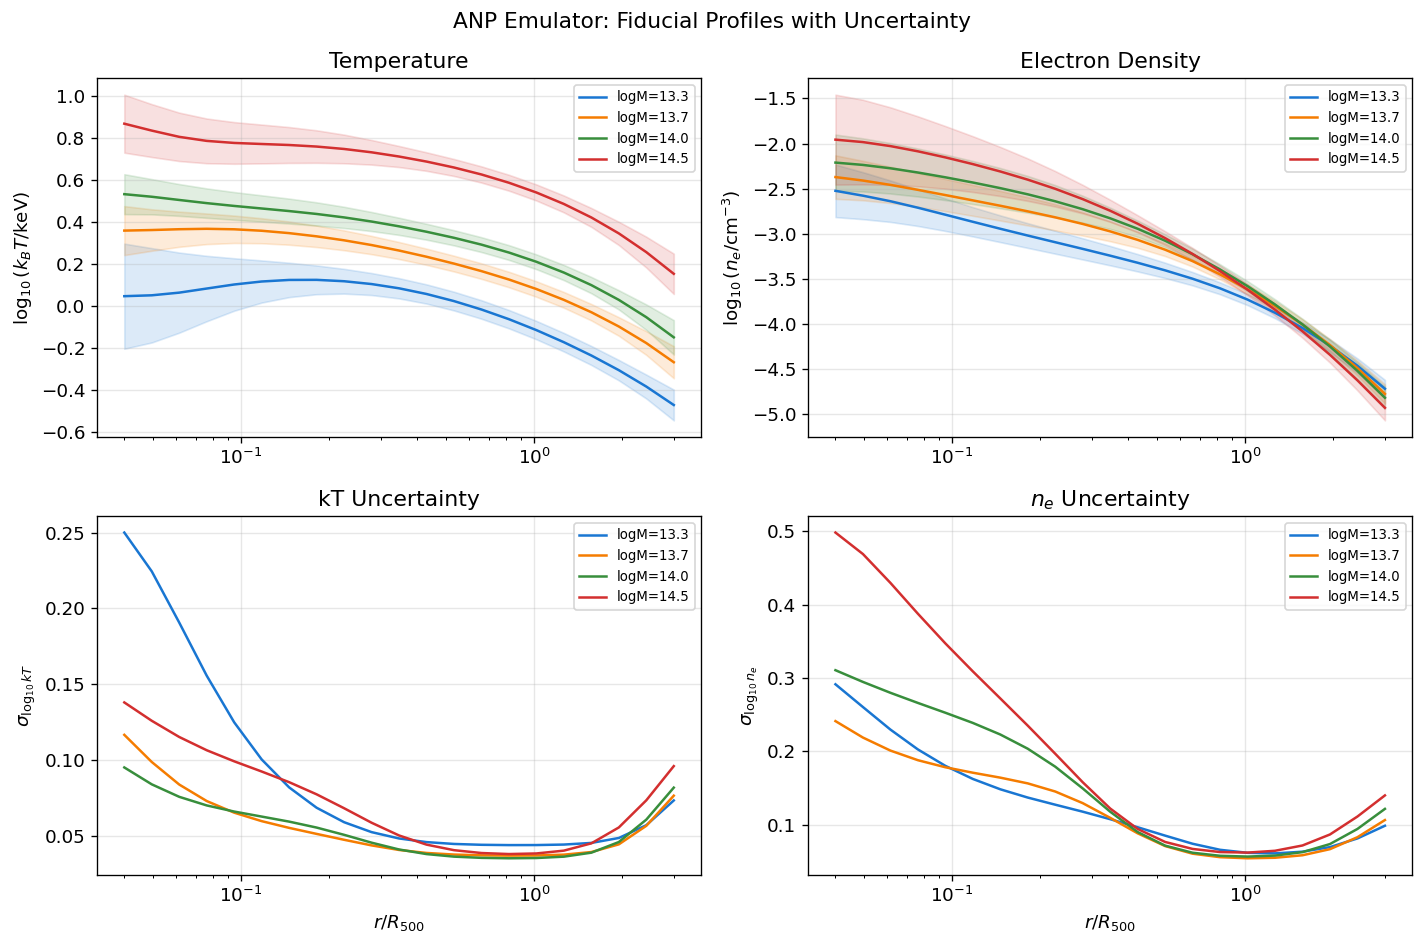

In [5]:
# Fiducial CAMELS parameters (IllustrisTNG)
FIDUCIAL_THETA = np.array([
    0.3, 0.8,           # Omega0, sigma8
    3.6, 1.0, 7.4, 20,  # Wind/Radio feedback
    0.049, 0.6711, 0.9624,  # OmegaBaryon, H0, n_s
    2.27, 0.3, -2.3, 8.0, 0.1, 0.0, 0.05, 350, 0.25,  # SF/wind
    0.002, 2.0, 0.6,    # wind energy reduction
    8e-5, 1.0, 1.0, 0.1, 0.2,  # BH params
    0.002, 2.0, 1.0, 0.0, 1.0, 0.0,  # UVB + quasar
    0.0013, 1.12, 2.0   # SNIa, softening
], dtype=np.float32)

# r/R500 grid (this is what the ANP expects)
r_over_R500 = np.logspace(np.log10(0.04), np.log10(3.0), 21).astype(np.float32)

test_logM = [13.3, 13.7, 14.0, 14.5]
test_masses = 10 ** np.array(test_logM, dtype=np.float32)

result = emu.predict(
    FIDUCIAL_THETA, M=test_masses, r_bins=r_over_R500,
    field=["temperature", "gas_density"], n_samples=20,
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = ["#1976D2", "#F57C00", "#388E3C", "#D32F2F"]

for i, (lm, c) in enumerate(zip(test_logM, colors)):
    # Temperature
    kT = result.mean[i, :, 0]  # keV
    kT_log = result.mean_log10[i, :, 0]
    kT_std_log = result.std_log10[i, :, 0]
    axes[0, 0].plot(r_over_R500, kT_log, color=c, label=f"logM={lm}")
    axes[0, 0].fill_between(r_over_R500, kT_log - kT_std_log, kT_log + kT_std_log,
                            alpha=0.15, color=c)

    # Gas density → n_e
    log_ne = result.mean_log10[i, :, 1] - LOG10_MU_E_MP
    ne_std_log = result.std_log10[i, :, 1]
    axes[0, 1].plot(r_over_R500, log_ne, color=c, label=f"logM={lm}")
    axes[0, 1].fill_between(r_over_R500, log_ne - ne_std_log, log_ne + ne_std_log,
                            alpha=0.15, color=c)

    # Uncertainties
    axes[1, 0].plot(r_over_R500, kT_std_log, color=c, label=f"logM={lm}")
    axes[1, 1].plot(r_over_R500, ne_std_log, color=c, label=f"logM={lm}")

for ax in axes[0]:
    ax.set_xscale("log")
    ax.legend(fontsize=8)
for ax in axes[1]:
    ax.set_xscale("log")
    ax.legend(fontsize=8)

axes[0, 0].set(ylabel=r"$\log_{10}(k_BT / \mathrm{keV})$", title="Temperature")
axes[0, 1].set(ylabel=r"$\log_{10}(n_e / \mathrm{cm}^{-3})$", title="Electron Density")
axes[1, 0].set(xlabel=r"$r / R_{500}$", ylabel=r"$\sigma_{\log_{10} kT}$", title="kT Uncertainty")
axes[1, 1].set(xlabel=r"$r / R_{500}$", ylabel=r"$\sigma_{\log_{10} n_e}$", title="$n_e$ Uncertainty")
fig.suptitle("ANP Emulator: Fiducial Profiles with Uncertainty", fontsize=13)
plt.tight_layout()
plt.show()

---
## 2. Load & Explore Training Data

We use the same CAMELS training data as `fit_data` to extract parameter ranges,
mass distributions, and radial grids.

In [6]:
train_data = np.load(DATA_DIR / "train_data_joint.npz", allow_pickle=True)

all_kT_raw = train_data["kT_profiles"]       # (N_halos, 25)
all_ne_raw = train_data["ne_profiles"]       # (N_halos, 25)
all_params = train_data["params"]            # (N_halos, 35)
all_M500c  = train_data["M500c"]             # (N_halos,)
all_R500c  = train_data["R500c"]             # (N_halos,)
all_sim_idx = train_data["sim_idx"]          # (N_halos,)
radial_bins_full = train_data["radial_bins"] # (25,) kpc
param_names = list(train_data["param_names"])
fiducial_params = train_data["fiducial_params"]

all_logM = np.log10(all_M500c)
n_halos_total = len(all_M500c)
n_sims = len(np.unique(all_sim_idx))

print(f"Training data: {n_halos_total:,} halos from {n_sims} simulations")
print(f"Parameters: {len(param_names)} (5 cosmo + 30 astro)")
print(f"Mass range: logM500c = [{all_logM.min():.2f}, {all_logM.max():.2f}]")

Training data: 59,843 halos from 1003 simulations
Parameters: 35 (5 cosmo + 30 astro)
Mass range: logM500c = [12.70, 14.97]


### 2.1 Mass Distribution

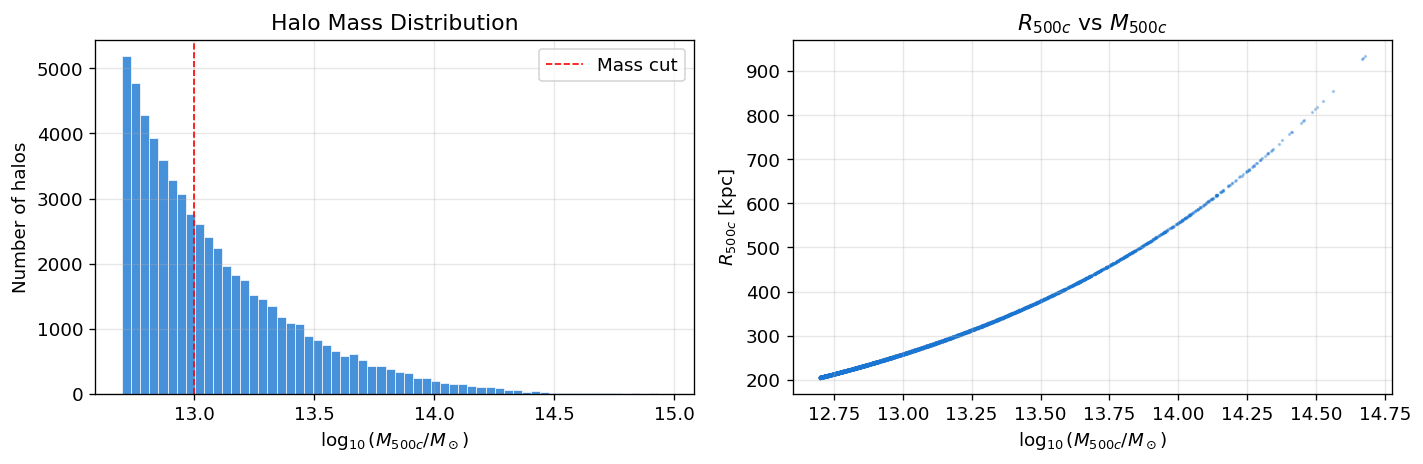

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(all_logM, bins=60, color="#1976D2", alpha=0.8, edgecolor="white", linewidth=0.5)
ax.set_xlabel(r"$\log_{10}(M_{500c} / M_\odot)$")
ax.set_ylabel("Number of halos")
ax.set_title("Halo Mass Distribution")
ax.axvline(13.0, color="red", ls="--", lw=1, label="Mass cut")
ax.legend()

# R500 vs M500
ax = axes[1]
ax.scatter(all_logM[::10], all_R500c[::10], s=1, alpha=0.3, c="#1976D2")
ax.set_xlabel(r"$\log_{10}(M_{500c} / M_\odot)$")
ax.set_ylabel(r"$R_{500c}$ [kpc]")
ax.set_title(r"$R_{500c}$ vs $M_{500c}$")
plt.tight_layout()
plt.show()

### 2.2 Parameter Space Coverage

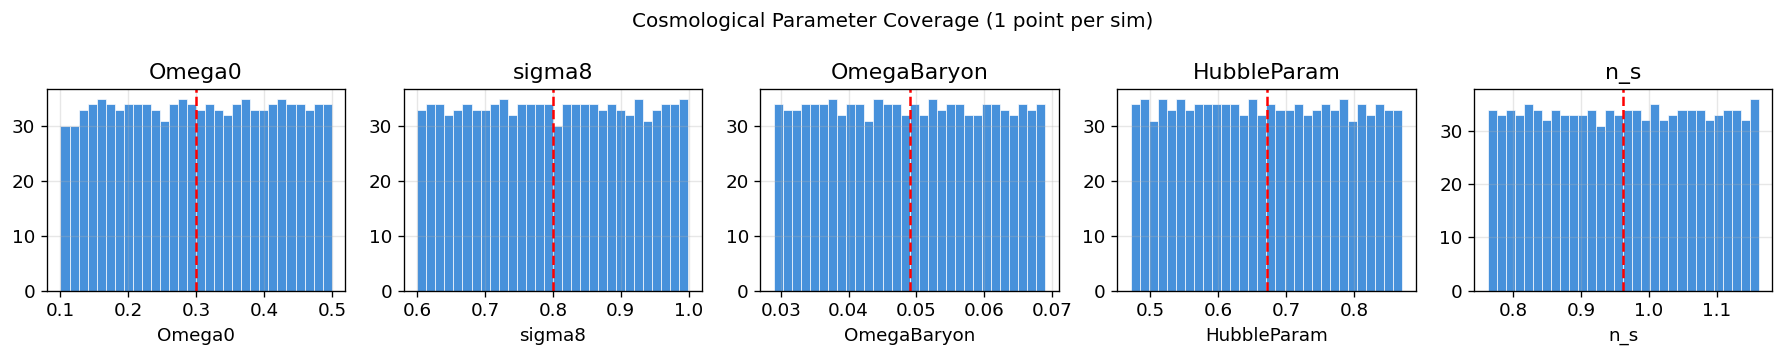

In [8]:
unique_sim_params = np.array([all_params[all_sim_idx == s][0] for s in np.unique(all_sim_idx)])
cosmo_idx = [i for i, p in enumerate(param_names) if p in COSMO_PARAMS]
cosmo_names = [param_names[i] for i in cosmo_idx]

fig, axes = plt.subplots(1, len(cosmo_idx), figsize=(3 * len(cosmo_idx), 3))
for j, (ci, cn) in enumerate(zip(cosmo_idx, cosmo_names)):
    axes[j].hist(unique_sim_params[:, ci], bins=30, color="#1976D2",
                 alpha=0.8, edgecolor="white", linewidth=0.5)
    axes[j].axvline(fiducial_params[ci], color="red", ls="--", lw=1.5)
    axes[j].set_xlabel(cn)
    axes[j].set_title(cn)
plt.suptitle("Cosmological Parameter Coverage (1 point per sim)", fontsize=12)
plt.tight_layout()
plt.show()

---
## 3. Load & Explore Observational Data

ACCEPT + X-COP clusters with $k_BT(r)$ and $n_e(r)$ profiles.

In [9]:
# Reference radial grid (same as fit_data emulator, after skipping inner 4)
INNER_SKIP = 4
radial_bins = radial_bins_full[INNER_SKIP:]  # 21 bins in kpc
n_radial = len(radial_bins)
log_emu_r = np.log10(radial_bins)

obs_file = np.load(DATA_DIR / "obs_expanded.npz", allow_pickle=True)
cluster_names = list(obs_file["cluster_names"])

rmin_emu = float(radial_bins[0])
rmax_emu = float(radial_bins[-1])

obs_logM = []
obs_kT_profiles = []
obs_ne_profiles = []
obs_R500_est = []
obs_z = []
obs_sources = []
obs_names_used = []

for name in cluster_names:
    has_kT_R = f"{name}__kT_R_kpc" in obs_file
    R_ne = obs_file[f"{name}__R_kpc"]
    kT = obs_file[f"{name}__kT"]
    kT_err = obs_file[f"{name}__kT_err"]
    ne = obs_file[f"{name}__ne"]
    ne_err = obs_file[f"{name}__ne_err"]
    logM_est = float(obs_file[f"{name}__logM500_est"])
    z = float(obs_file[f"{name}__z"])
    source = str(obs_file[f"{name}__source"])

    if logM_est > OBS_LOGM_MAX or logM_est < 13.2:
        continue

    # n_e profile: interpolate to reference radial grid
    good_ne = ((R_ne >= rmin_emu * 0.8) & (R_ne <= rmax_emu * 1.2) &
               (ne > 0) & (ne_err > 0))
    if np.sum(good_ne) < 3:
        continue
    ne_interp = np.interp(log_emu_r, np.log10(R_ne[good_ne]),
                          np.log10(ne[good_ne]), left=np.nan, right=np.nan)

    # kT profile
    if has_kT_R:
        R_kT = obs_file[f"{name}__kT_R_kpc"]
        good_kT = ((R_kT >= rmin_emu * 0.8) & (R_kT <= rmax_emu * 1.2) &
                    (kT > 0) & (kT_err > 0))
    else:
        good_kT = ((R_ne >= rmin_emu * 0.8) & (R_ne <= rmax_emu * 1.2) &
                    (kT > 0) & (kT_err > 0))
    if np.sum(good_kT) < 3:
        continue

    if has_kT_R:
        kT_interp = np.interp(log_emu_r, np.log10(R_kT[good_kT]),
                              np.log10(kT[good_kT]), left=np.nan, right=np.nan)
    else:
        kT_interp = np.interp(log_emu_r, np.log10(R_ne[good_kT]),
                              np.log10(kT[good_kT]), left=np.nan, right=np.nan)

    # Estimate R500 from mass using a simple scaling (R500 ~ M^{1/3})
    # R500 ≈ 550 kpc × (M500 / 1e14)^{1/3} (approximate at z~0)
    R500_est = 550.0 * (10 ** (logM_est - 14.0)) ** (1.0 / 3.0)

    obs_logM.append(logM_est)
    obs_kT_profiles.append(kT_interp)   # log10(kT/keV)
    obs_ne_profiles.append(ne_interp)    # log10(ne/cm^-3)
    obs_R500_est.append(R500_est)
    obs_z.append(z)
    obs_sources.append(source)
    obs_names_used.append(name)

obs_logM = np.array(obs_logM)
obs_kT_profiles = np.array(obs_kT_profiles)      # (n_obs, n_radial) — log10(keV)
obs_ne_profiles = np.array(obs_ne_profiles)       # (n_obs, n_radial) — log10(cm^-3)
obs_P_profiles = obs_kT_profiles + obs_ne_profiles  # log10(P) = log10(kT) + log10(ne)
obs_R500_est = np.array(obs_R500_est)
obs_z = np.array(obs_z)
obs_sources = np.array(obs_sources)
n_obs_clusters = len(obs_logM)

n_accept_src = (obs_sources == "ACCEPT").sum()
n_xcop_src = (obs_sources == "XCOP").sum()
print(f"Loaded {n_obs_clusters} clusters: {n_accept_src} ACCEPT + {n_xcop_src} X-COP")
print(f"Mass range: logM ∈ [{obs_logM.min():.2f}, {obs_logM.max():.2f}]")
print(f"Redshift range: z ∈ [{obs_z.min():.3f}, {obs_z.max():.3f}]")

Loaded 129 clusters: 121 ACCEPT + 8 X-COP
Mass range: logM ∈ [13.23, 14.88]
Redshift range: z ∈ [0.003, 0.545]


### 3.1 Observed Profiles

/mnt/home/mlee1/venvs/torch3/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


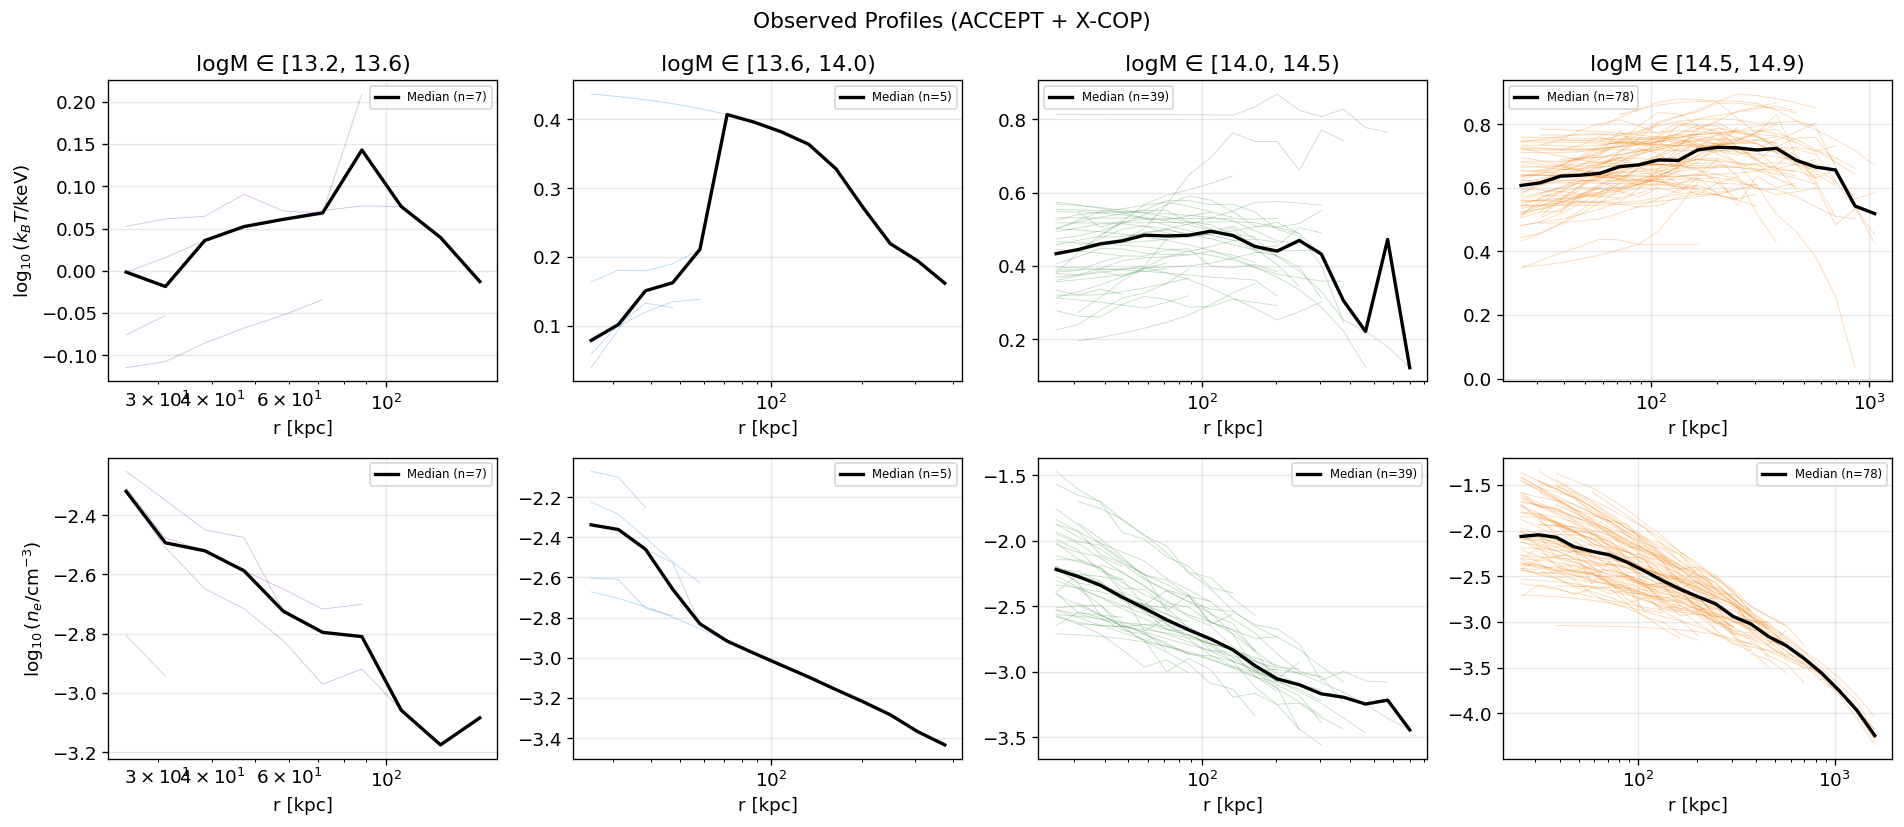

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

mass_ranges = [(13.2, 13.6), (13.6, 14.0), (14.0, 14.5), (14.5, OBS_LOGM_MAX)]
colors_obs = ["#7B1FA2", "#1976D2", "#388E3C", "#F57C00"]

for col, (mlo, mhi) in enumerate(mass_ranges):
    in_bin = (obs_logM >= mlo) & (obs_logM < mhi)
    n_in = in_bin.sum()

    for j in np.where(in_bin)[0]:
        axes[0, col].plot(radial_bins, obs_kT_profiles[j], color=colors_obs[col],
                          alpha=0.3, lw=0.5)
        axes[1, col].plot(radial_bins, obs_ne_profiles[j], color=colors_obs[col],
                          alpha=0.3, lw=0.5)

    if n_in > 0:
        axes[0, col].plot(radial_bins, np.nanmedian(obs_kT_profiles[in_bin], axis=0),
                          "k-", lw=2, label=f"Median (n={n_in})")
        axes[1, col].plot(radial_bins, np.nanmedian(obs_ne_profiles[in_bin], axis=0),
                          "k-", lw=2, label=f"Median (n={n_in})")

    axes[0, col].set_title(f"logM ∈ [{mlo}, {mhi})")
    for row in range(2):
        axes[row, col].set_xscale("log")
        axes[row, col].legend(fontsize=7)
        axes[row, col].set_xlabel("r [kpc]")

axes[0, 0].set_ylabel(r"$\log_{10}(k_BT / \mathrm{keV})$")
axes[1, 0].set_ylabel(r"$\log_{10}(n_e / \mathrm{cm}^{-3})$")
fig.suptitle("Observed Profiles (ACCEPT + X-COP)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Forward Model: ANP-Based Population Simulation

For each θ (parameter vector), the forward model:
1. Draws cluster masses from each mass bin (matching the observed count)
2. Calls the **ANP** emulator to get predicted kT and gas_density profiles
3. Converts gas_density → n_e and uses the ANP's own uncertainty as intrinsic scatter
4. Compresses to an adaptive summary vector (medians per mass bin + scalars)

### 4.1 Mass Bins & Summary Layout

In [11]:
mass_bin_edges = np.array([13.2, 13.6, 14.0, 14.5, OBS_LOGM_MAX])
mass_bin_centers = 0.5 * (mass_bin_edges[:-1] + mass_bin_edges[1:])
n_mass_bins = len(mass_bin_centers)

# Clusters per mass bin
n_per_bin = np.zeros(n_mass_bins, dtype=int)
for mb in range(n_mass_bins):
    in_bin = (obs_logM >= mass_bin_edges[mb]) & (obs_logM < mass_bin_edges[mb + 1])
    n_per_bin[mb] = in_bin.sum()
print(f"Clusters per mass bin: {n_per_bin} (total {n_per_bin.sum()})")

# Adaptive radii per mass bin — subsample from the reference grid
radii_per_bin = []
for mb in range(n_mass_bins):
    if mb == 0:    max_r = 60.0     # [13.2-13.6): small groups
    elif mb == 1:  max_r = 100.0    # [13.6-14.0): groups
    elif mb == 2:  max_r = 300.0    # [14.0-14.5): clusters
    else:          max_r = 600.0    # [14.5-14.9): massive clusters

    valid_r = np.where(radial_bins <= max_r)[0]
    if len(valid_r) > 5:
        valid_r = valid_r[np.linspace(0, len(valid_r) - 1, 5).astype(int)]
    radii_per_bin.append(valid_r)

n_obs_types = 3  # kT, ne, P
n_scalar_per_bin = 2  # log(1+n_clusters), median_logM

summary_dims_per_bin = []
n_summary = 0
for mb in range(n_mass_bins):
    nr = len(radii_per_bin[mb])
    dims = nr * n_obs_types + n_scalar_per_bin
    summary_dims_per_bin.append(dims)
    n_summary += dims

print(f"\nSummary statistics: {n_summary} dimensions across {n_mass_bins} mass bins")
for mb in range(n_mass_bins):
    nr = len(radii_per_bin[mb])
    r_range = f"{radial_bins[radii_per_bin[mb][0]]:.0f}–{radial_bins[radii_per_bin[mb][-1]]:.0f}"
    print(f"  Bin {mb} [{mass_bin_edges[mb]:.1f}–{mass_bin_edges[mb+1]:.1f}): "
          f"{nr} radii ({r_range} kpc) × 3 obs + 2 scalars = {summary_dims_per_bin[mb]} dims")

Clusters per mass bin: [ 7  5 39 78] (total 129)

Summary statistics: 68 dimensions across 4 mass bins
  Bin 0 [13.2–13.6): 5 radii (25–58 kpc) × 3 obs + 2 scalars = 17 dims
  Bin 1 [13.6–14.0): 5 radii (25–88 kpc) × 3 obs + 2 scalars = 17 dims
  Bin 2 [14.0–14.5): 5 radii (25–248 kpc) × 3 obs + 2 scalars = 17 dims
  Bin 3 [14.5–14.9): 5 radii (25–568 kpc) × 3 obs + 2 scalars = 17 dims


### 4.2 Compute Observed Summary

In [12]:
def compute_summary(logM_arr, kT_arr, ne_arr, P_arr):
    """Compute adaptive population summary vector."""
    summary = np.zeros(n_summary)
    offset = 0
    for mb in range(n_mass_bins):
        in_bin = ((logM_arr >= mass_bin_edges[mb]) &
                  (logM_arr < mass_bin_edges[mb + 1]))
        n_in = in_bin.sum()
        r_idx = radii_per_bin[mb]
        nr = len(r_idx)

        if n_in >= 1:
            kT_med = np.nanmedian(kT_arr[in_bin][:, r_idx], axis=0)
            ne_med = np.nanmedian(ne_arr[in_bin][:, r_idx], axis=0)
            P_med = np.nanmedian(P_arr[in_bin][:, r_idx], axis=0)
            median_logM = np.median(logM_arr[in_bin])
        else:
            kT_med = np.zeros(nr)
            ne_med = np.zeros(nr)
            P_med = np.zeros(nr)
            median_logM = mass_bin_centers[mb]

        kT_med = np.nan_to_num(kT_med, nan=0.0)
        ne_med = np.nan_to_num(ne_med, nan=0.0)
        P_med = np.nan_to_num(P_med, nan=0.0)

        summary[offset:offset + nr] = kT_med;   offset += nr
        summary[offset:offset + nr] = ne_med;    offset += nr
        summary[offset:offset + nr] = P_med;     offset += nr
        summary[offset] = np.log1p(n_in);        offset += 1
        summary[offset] = median_logM;            offset += 1
    return summary


x_obs = compute_summary(obs_logM, obs_kT_profiles, obs_ne_profiles, obs_P_profiles)
print(f"Observed summary: {n_summary} dims, non-zero: {(x_obs != 0).sum()}")
print(f"Clusters per mass bin: {n_per_bin} (total {n_per_bin.sum()})")

Observed summary: 68 dims, non-zero: 68
Clusters per mass bin: [ 7  5 39 78] (total 129)


### 4.3 R500 Estimation

The ANP takes `r/R500` as input. We need to estimate R500 from M500 for each halo.
We fit a simple relation from the CAMELS training data.

In [13]:
# Fit R500(M500) relation from CAMELS data
mass_mask = all_logM >= 13.0
logR_train = np.log10(all_R500c[mass_mask])
logM_train = all_logM[mass_mask]

# Simple linear fit: log10(R500) = a * log10(M500) + b
coeffs = np.polyfit(logM_train, logR_train, 1)
print(f"R500(M500) fit: log10(R500) = {coeffs[0]:.4f} * log10(M500) + {coeffs[1]:.4f}")

def estimate_R500(logM):
    """Estimate R500 [kpc] from log10(M500/Msun) using the CAMELS relation."""
    return 10 ** np.polyval(coeffs, logM)

# Verify
for lm in [13.3, 13.7, 14.0, 14.5]:
    R_est = estimate_R500(lm)
    mask = (all_logM > lm - 0.1) & (all_logM < lm + 0.1)
    R_actual = np.median(all_R500c[mask]) if mask.sum() > 0 else np.nan
    print(f"  logM={lm}: R500_fit={R_est:.0f} kpc, R500_data={R_actual:.0f} kpc")

R500(M500) fit: log10(R500) = 0.3333 * log10(M500) + -1.9214
  logM=13.3: R500_fit=325 kpc, R500_data=322 kpc
  logM=13.7: R500_fit=442 kpc, R500_data=437 kpc
  logM=14.0: R500_fit=556 kpc, R500_data=549 kpc
  logM=14.5: R500_fit=816 kpc, R500_data=792 kpc


### 4.4 Prior Definition

When `FIX_COSMO=True`, the 5 cosmological parameters (Ω₀, σ₈, Ω_b, H₀, n_s)
are held at their Planck fiducial values and only the 30 astrophysical parameters
are explored. Set `FIX_COSMO=False` to explore all 35 parameters jointly.

In [14]:
from sbi.utils import BoxUniform

# ── Determine free vs fixed parameters ──
all_param_names = list(param_names)  # full 35

if FIX_COSMO:
    # Only explore astrophysical parameters; cosmo fixed at fiducial
    free_idx_full = [i for i, pn in enumerate(all_param_names) if pn not in COSMO_PARAMS]
    fixed_idx_full = [i for i, pn in enumerate(all_param_names) if pn in COSMO_PARAMS]
    fiducial_cosmo_values = FIDUCIAL_THETA[fixed_idx_full]
    print(f"FIX_COSMO=True — fixing {len(fixed_idx_full)} cosmo params at fiducial:")
    for ci in fixed_idx_full:
        print(f"  {all_param_names[ci]:20s} = {FIDUCIAL_THETA[ci]:.6g}")
else:
    free_idx_full = list(range(len(all_param_names)))
    fixed_idx_full = []
    fiducial_cosmo_values = np.array([])

free_idx_full = np.array(free_idx_full)
fixed_idx_full = np.array(fixed_idx_full)

selected_param_names = [all_param_names[i] for i in free_idx_full]
n_params = len(selected_param_names)

# Bounds from training data (free params only)
bounds_lo = np.array([all_params[:, i].min() for i in free_idx_full])
bounds_hi = np.array([all_params[:, i].max() for i in free_idx_full])

LOG_UNIFORM_NAMES = {
    "WindEnergyIn1e51erg", "RadioFeedbackFactor", "VariableWindVelFactor",
    "RadioFeedbackReiorientationFactor", "MaxSfrTimescale", "FactorForSofterEQS",
    "ThermalWindFraction", "WindFreeTravelDensFac", "WindEnergyReductionFactor",
    "WindEnergyReductionMetallicity", "SeedBlackHoleMass", "BlackHoleAccretionFactor",
    "BlackHoleEddingtonFactor", "BlackHoleFeedbackFactor", "BlackHoleRadiativeEfficiency",
    "QuasarThreshold", "UVBH0beta", "UVBHepbeta", "SofteningComovingType01",
}

is_log_param = np.array([pn in LOG_UNIFORM_NAMES for pn in selected_param_names])
log_idx = np.where(is_log_param)[0]
lin_idx = np.where(~is_log_param)[0]

# Transform bounds to internal (log10) space
prior_bounds_lo = bounds_lo.copy()
prior_bounds_hi = bounds_hi.copy()
prior_bounds_lo[log_idx] = np.log10(bounds_lo[log_idx])
prior_bounds_hi[log_idx] = np.log10(bounds_hi[log_idx])

sbi_prior = BoxUniform(
    low=torch.tensor(prior_bounds_lo, dtype=torch.float32, device=DEVICE),
    high=torch.tensor(prior_bounds_hi, dtype=torch.float32, device=DEVICE),
)

def theta_to_physical(theta_internal):
    """Internal (log10 for log-uniform) → physical (free params only)."""
    t = theta_internal.copy()
    t[..., log_idx] = 10.0 ** t[..., log_idx]
    return t

def theta_to_internal(theta_phys):
    """Physical → internal (log10 for log-uniform) (free params only)."""
    t = theta_phys.copy()
    t[..., log_idx] = np.log10(t[..., log_idx])
    return t

def expand_to_full_theta(theta_free_phys):
    """Expand free-param physical theta to full 35-param vector.
    Inserts fiducial values for any fixed (cosmo) parameters.
    Works for shape (N, n_free) or (n_free,)."""
    if len(fixed_idx_full) == 0:
        return theta_free_phys  # nothing to expand
    squeeze = theta_free_phys.ndim == 1
    if squeeze:
        theta_free_phys = theta_free_phys[None, :]
    N = theta_free_phys.shape[0]
    full = np.zeros((N, len(all_param_names)), dtype=theta_free_phys.dtype)
    full[:, free_idx_full] = theta_free_phys
    full[:, fixed_idx_full] = fiducial_cosmo_values
    if squeeze:
        full = full[0]
    return full

mode_str = "ASTRO-ONLY" if FIX_COSMO else "ALL PARAMS"
print(f"Prior ({mode_str}): {n_params} params ({len(log_idx)} log-uniform, {len(lin_idx)} linear)")

2026-04-05 19:55:51.066657: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-05 19:55:51.636368: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.


FIX_COSMO=True — fixing 5 cosmo params at fiducial:
  Omega0               = 0.3
  sigma8               = 0.8
  OmegaBaryon          = 0.049
  HubbleParam          = 0.6711
  n_s                  = 0.9624
Prior (ASTRO-ONLY): 30 params (19 log-uniform, 11 linear)


### 4.5 Generate Training Simulations with ANP

This is the core loop: for each θ drawn from the prior, we simulate a cluster
population using the ANP emulator and compress to a summary vector.

The ANP provides per-prediction uncertainty which we use as the intrinsic scatter
model — **no separate scatter table is needed**.

In [15]:
# Sample from prior (free params only)
theta_internal = sbi_prior.sample((N_SIMS,))
theta_phys = theta_internal.clone()
theta_phys[:, log_idx] = 10.0 ** theta_phys[:, log_idx]
theta_phys_np = theta_phys.cpu().numpy()

# Expand to full 35-param vector (inserts fiducial cosmo values if FIX_COSMO)
theta_full_np = expand_to_full_theta(theta_phys_np)

x_all = np.zeros((N_SIMS, n_summary), dtype=np.float32)
rng = np.random.RandomState(12345)
t0 = time.time()

# ── GPU-batched forward model ──
# We batch ALL halos in a mass bin into a single predict() call by
# flattening (sims × halos) into one batch dimension.  This eliminates
# the inner per-halo loop and cuts GPU call count by ~n_halos_bin×.
MAX_GPU_ROWS = 16384  # max (sim × halo) rows per predict() call

for mb in range(n_mass_bins):
    n_halos_bin = n_per_bin[mb]
    r_idx = radii_per_bin[mb]
    nr = len(r_idx)
    offset_mb = sum(summary_dims_per_bin[:mb])

    if n_halos_bin == 0:
        scalar_offset = offset_mb + nr * n_obs_types
        x_all[:, scalar_offset] = 0.0
        x_all[:, scalar_offset + 1] = mass_bin_centers[mb]
        print(f"  Bin {mb}: 0 halos, skipping")
        continue

    # Draw random masses within this bin for each simulation
    masses_sim = rng.uniform(mass_bin_edges[mb], mass_bin_edges[mb + 1],
                             size=(N_SIMS, n_halos_bin))  # logM values

    # Storage for profiles: (N_SIMS, n_halos_bin, n_radial) in log10 space
    kT_profiles = np.zeros((N_SIMS, n_halos_bin, n_radial))
    ne_profiles = np.zeros((N_SIMS, n_halos_bin, n_radial))

    # Sims per GPU call — limited so (sims_per_call * n_halos_bin) fits in VRAM
    sims_per_call = max(1, MAX_GPU_ROWS // n_halos_bin)

    for si in range(0, N_SIMS, sims_per_call):
        se = min(si + sims_per_call, N_SIMS)
        bs = se - si  # actual sims in this batch

        # Flatten: (bs, n_halos_bin) → (bs * n_halos_bin,) for mass/R500/r_bins
        flat_logM = masses_sim[si:se].ravel()                 # (bs * n_halos_bin,)
        flat_M = 10.0 ** flat_logM                            # solar masses
        flat_R500 = estimate_R500(flat_logM)                  # kpc
        flat_r_over_R500 = (radial_bins[None, :] / flat_R500[:, None]).astype(np.float32)

        # Repeat theta for each halo: (bs, 35) → (bs * n_halos_bin, 35)
        flat_theta = np.repeat(theta_full_np[si:se], n_halos_bin, axis=0)

        # Single predict() call for all sims × all halos in this bin
        result_i = emu.predict(
            flat_theta,                         # (bs*n_h, 35)
            M=flat_M,                           # (bs*n_h,)
            r_bins=flat_r_over_R500,            # (bs*n_h, n_radial)
            field=["temperature", "gas_density"],
            n_samples=N_ANP_SAMPLES,
        )

        # Reshape back to (bs, n_halos_bin, n_radial, 2)
        log_kT = result_i.mean_log10[:, :, 0].reshape(bs, n_halos_bin, n_radial)
        log_rho = result_i.mean_log10[:, :, 1].reshape(bs, n_halos_bin, n_radial)
        log_ne = log_rho - LOG10_MU_E_MP

        std_kT = result_i.std_log10[:, :, 0].reshape(bs, n_halos_bin, n_radial)
        std_ne = result_i.std_log10[:, :, 1].reshape(bs, n_halos_bin, n_radial)

        noise_kT = rng.randn(bs, n_halos_bin, n_radial) * std_kT
        noise_ne = rng.randn(bs, n_halos_bin, n_radial) * std_ne

        kT_profiles[si:se] = log_kT + noise_kT
        ne_profiles[si:se] = log_ne + noise_ne

    # Compute summary: P = kT × ne → log10(P) = log10(kT) + log10(ne)
    P_profiles = kT_profiles + ne_profiles

    kT_med = np.median(kT_profiles[:, :, r_idx], axis=1)  # (N_SIMS, nr)
    ne_med = np.median(ne_profiles[:, :, r_idx], axis=1)
    P_med = np.median(P_profiles[:, :, r_idx], axis=1)
    median_mass = np.median(masses_sim, axis=1)

    off = offset_mb
    x_all[:, off:off + nr] = kT_med;       off += nr
    x_all[:, off:off + nr] = ne_med;        off += nr
    x_all[:, off:off + nr] = P_med;         off += nr
    x_all[:, off] = np.log1p(n_halos_bin);  off += 1
    x_all[:, off] = median_mass;            off += 1

    elapsed_bin = time.time() - t0
    n_calls = int(np.ceil(N_SIMS / sims_per_call))
    print(f"  Bin {mb} [{mass_bin_edges[mb]:.1f}–{mass_bin_edges[mb+1]:.1f}): "
          f"{n_halos_bin} halos/sim, {n_calls} GPU calls — {elapsed_bin:.1f}s elapsed")

elapsed = time.time() - t0
print(f"\nGenerated {N_SIMS:,} simulated summaries in {elapsed:.1f}s")
print(f"x_all shape: {x_all.shape}")

  Bin 0 [13.2–13.6): 7 halos/sim, 86 GPU calls — 49.6s elapsed
  Bin 1 [13.6–14.0): 5 halos/sim, 62 GPU calls — 85.1s elapsed
  Bin 2 [14.0–14.5): 39 halos/sim, 477 GPU calls — 360.2s elapsed
  Bin 3 [14.5–14.9): 78 halos/sim, 953 GPU calls — 911.5s elapsed

Generated 200,000 simulated summaries in 911.5s
x_all shape: (200000, 68)


### 4.6 Coverage Check

Verify that the observed summary lies within the simulated range.

In [16]:
sim_min = x_all.min(axis=0)
sim_max = x_all.max(axis=0)
in_range = (x_obs >= sim_min) & (x_obs <= sim_max)
nonzero = x_obs != 0

print(f"Coverage: {in_range.sum()}/{n_summary} dims within sim range")
print(f"  ({in_range[nonzero].sum()}/{nonzero.sum()} non-zero dims)")

if (~in_range & nonzero).any():
    print("\nOut-of-range dims:")
    for i in np.where(~in_range & nonzero)[0]:
        print(f"  dim {i}: obs={x_obs[i]:.4f}, sim=[{sim_min[i]:.4f}, {sim_max[i]:.4f}]")

Coverage: 60/68 dims within sim range
  (60/68 non-zero dims)

Out-of-range dims:
  dim 15: obs=2.0794, sim=[2.0794, 2.0794]
  dim 32: obs=1.7918, sim=[1.7918, 1.7918]
  dim 49: obs=3.6889, sim=[3.6889, 3.6889]
  dim 52: obs=0.6395, sim=[0.6557, 1.1717]
  dim 53: obs=0.6876, sim=[0.6937, 1.0591]
  dim 63: obs=-1.7866, sim=[-1.6844, -0.9056]
  dim 64: obs=-2.0950, sim=[-2.0186, -1.4352]
  dim 66: obs=4.3694, sim=[4.3694, 4.3694]


### 4.7 Visualize Simulated vs Observed Summaries

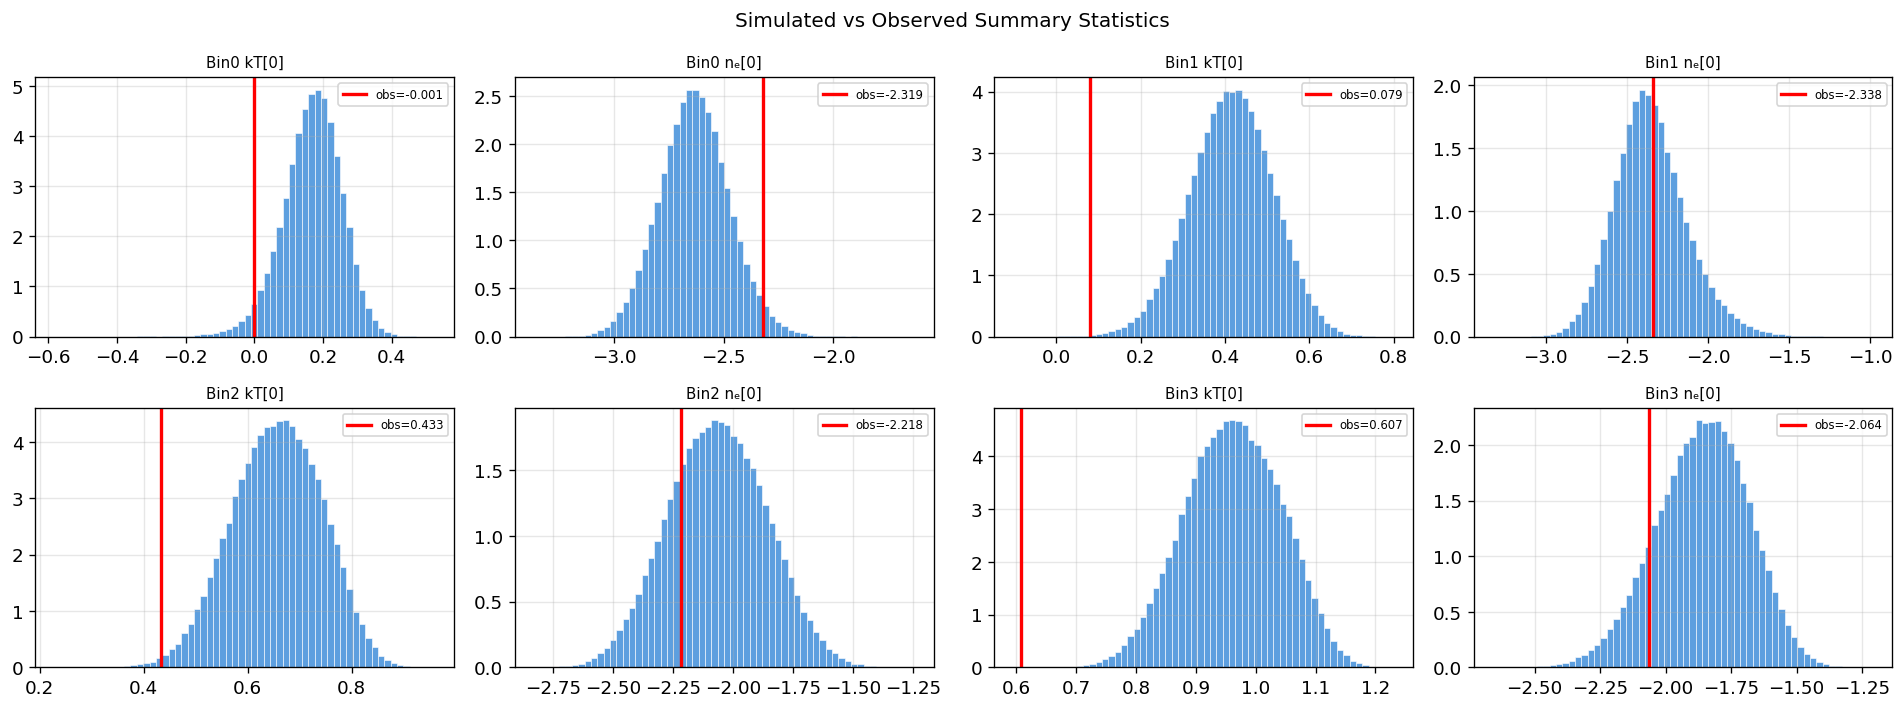

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

check_dims = []
offset = 0
for mb in range(n_mass_bins):
    nr = len(radii_per_bin[mb])
    check_dims.append((offset, f"Bin{mb} kT[0]"))
    check_dims.append((offset + nr, f"Bin{mb} nₑ[0]"))
    offset += summary_dims_per_bin[mb]

for j, (di, label) in enumerate(check_dims):
    if j >= 8:
        break
    ax = axes.flat[j]
    sim_vals = x_all[:, di]
    ax.hist(sim_vals, bins=60, density=True, alpha=0.7, color="#1976D2",
            edgecolor="white", linewidth=0.5)
    ax.axvline(x_obs[di], color="red", lw=2, label=f"obs={x_obs[di]:.3f}")
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle("Simulated vs Observed Summary Statistics", fontsize=12)
plt.tight_layout()
plt.show()

---
## 5. Simulation-Based Inference (NPE)

We use **Neural Posterior Estimation** (NPE-C) from the `sbi` library.
The network learns $p(\theta | x)$ directly from (θ, x) pairs,
then we condition on $x_{\text{obs}}$ to get the posterior.

### 5.1 Train NPE

In [18]:
from sbi.inference import NPE

theta_train = theta_internal.cpu().float()
x_train = torch.tensor(x_all, dtype=torch.float32)

mode_str = "ASTRO-ONLY (cosmo fixed)" if FIX_COSMO else "ALL 35 PARAMS"
print(f"Training NPE ({mode_str}): {N_SIMS:,} sims, {n_summary} summary dims, {n_params} free params")
print(f"  θ shape: {theta_train.shape}, x shape: {x_train.shape}")

inference = NPE(prior=sbi_prior, device=str(DEVICE))
inference.append_simulations(theta_train, x_train)

t0 = time.time()
density_estimator = inference.train(
    max_num_epochs=MAX_EPOCHS,
    training_batch_size=256,
    stop_after_epochs=30,
    show_train_summary=True,
)
train_time = time.time() - t0
print(f"\nNPE training completed in {train_time:.1f}s")

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Training NPE (ASTRO-ONLY (cosmo fixed)): 200,000 sims, 68 summary dims, 30 free params
  θ shape: torch.Size([200000, 30]), x shape: torch.Size([200000, 68])


/mnt/home/mlee1/venvs/torch3/lib/python3.10/site-packages/sbi/inference/trainers/npe/npe_base.py:177: UserWarning: Data x has device 'cpu'. Moving x to the data_device 'cuda'. Training will proceed on device 'cuda'.
  theta, x = validate_theta_and_x(
/mnt/home/mlee1/venvs/torch3/lib/python3.10/site-packages/sbi/inference/trainers/npe/npe_base.py:177: UserWarning: Parameters theta has device 'cpu'. Moving theta to the data_device 'cuda'. Training will proceed on device 'cuda'.
  theta, x = validate_theta_and_x(


 Training neural network. Epochs trained: 201
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 201
        Best validation performance: 15.7815
        -------------------------
        

NPE training completed in 1522.8s


### 5.2 Sample Posterior

In [19]:
posterior = inference.build_posterior(density_estimator)

# Save posterior
TAG = "anp_npe_astro_only_v1" if FIX_COSMO else "anp_npe_v1"
de_path = RESULTS_DIR / f"{TAG}_posterior.pkl"
with open(de_path, "wb") as f:
    pickle.dump(posterior, f)
print(f"Saved posterior to {de_path}")

# Sample
x_obs_t = torch.tensor(x_obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
t0 = time.time()
try:
    samples_raw = posterior.sample((N_POSTERIOR,), x=x_obs_t)
    samples_internal = samples_raw.cpu().numpy()
    print("Rejection sampling succeeded.")
except Exception as e:
    print(f"Rejection failed ({e}), using direct flow sampling...")
    samples_raw = posterior.posterior_estimator.sample(
        (N_POSTERIOR,), condition=x_obs_t)
    samples_internal = samples_raw.detach().cpu().numpy()

if samples_internal.ndim == 3:
    samples_internal = samples_internal.reshape(-1, samples_internal.shape[-1])

samples_internal = np.clip(samples_internal, prior_bounds_lo, prior_bounds_hi)
samples_phys = theta_to_physical(samples_internal)

# Also build full 35-param samples for any downstream use
samples_phys_full = expand_to_full_theta(samples_phys)

print(f"Sampled {N_POSTERIOR:,} posterior draws in {time.time() - t0:.1f}s")
if FIX_COSMO:
    print(f"  Free params: {n_params} astro | Fixed cosmo at fiducial")

Saved posterior to ../sbi_results/anp_npe_astro_only_v1_posterior.pkl


  0%|          | 0/50000 [00:00<?, ?it/s]

Rejection sampling succeeded.
Sampled 50,000 posterior draws in 5.0s
  Free params: 30 astro | Fixed cosmo at fiducial


### 5.3 Constraints Summary

In [20]:
print(f"{'=' * 75}")
print(f"POSTERIOR CONSTRAINTS — {TAG}")
print(f"{'=' * 75}")
print(f"{'Parameter':35s}  {'Type':5s}  {'Median':>10s}  {'16%':>10s}  {'84%':>10s}  {'w/prior':>7s}")
print(f"{'-' * 75}")

n_constrained = 0
n_railing = 0
constraints = {}

for pi in range(n_params):
    pn = selected_param_names[pi]
    is_cosmo = pn in COSMO_PARAMS
    vals = samples_phys[:, pi]
    vals_int = samples_internal[:, pi]

    p16, p50, p84 = np.percentile(vals, [16, 50, 84])
    p5, p95 = np.percentile(vals, [5, 95])
    prior_width = bounds_hi[pi] - bounds_lo[pi]
    width_frac = (p84 - p16) / prior_width

    # Railing check
    int_range = prior_bounds_hi[pi] - prior_bounds_lo[pi]
    at_lo = np.mean(vals_int < prior_bounds_lo[pi] + 0.02 * int_range)
    at_hi = np.mean(vals_int > prior_bounds_hi[pi] - 0.02 * int_range)
    rail_pct = max(at_lo, at_hi) * 100

    ptype = "COSMO" if is_cosmo else "astro"
    flag = ""
    if width_frac < 0.7:
        n_constrained += 1
        flag = " ✓"
    if rail_pct > 20:
        n_railing += 1
        flag += " ⚠rail"

    constraints[pn] = {
        "median": float(p50), "p16": float(p16), "p84": float(p84),
        "p5": float(p5), "p95": float(p95),
        "width_frac": float(width_frac), "rail_pct": float(rail_pct),
        "is_cosmo": is_cosmo,
    }

    print(f"{pn:35s}  {ptype:5s}  {p50:10.4g}  {p16:10.4g}  {p84:10.4g}  {width_frac:7.2f}{flag}")

print(f"\n{n_constrained}/{n_params} params constrained (w/prior < 0.7)")
print(f"{n_railing}/{n_params} params railing (>20% at boundary)")

POSTERIOR CONSTRAINTS — anp_npe_astro_only_v1
Parameter                            Type       Median         16%         84%  w/prior
---------------------------------------------------------------------------
WindEnergyIn1e51erg                  astro       7.189       4.114       10.01     0.44 ✓
RadioFeedbackFactor                  astro      0.6896      0.3348       1.775     0.38 ✓
VariableWindVelFactor                astro       14.11       13.38       14.59     0.11 ✓ ⚠rail
RadioFeedbackReiorientationFactor    astro       29.06        19.5       35.56     0.54 ✓
MaxSfrTimescale                      astro       2.624       1.818       3.618     0.53 ✓
FactorForSofterEQS                   astro      0.3119      0.1798      0.5326     0.44 ✓
IMFslope                             astro      -2.575      -2.675      -2.452     0.22 ✓
SNII_MinMass_Msun                    astro       9.326       6.648       11.16     0.56 ✓
ThermalWindFraction                  astro      0.1296     0.061

### 5.4 Corner Plot — Cosmological Parameters (skipped if `FIX_COSMO=True`)

In [ ]:
import corner

cosmo_idx_list = [i for i, p in enumerate(selected_param_names) if p in COSMO_PARAMS]

if len(cosmo_idx_list) == 0:
    print("Cosmo parameters are fixed — skipping cosmological corner plot.")
    if FIX_COSMO:
        print("Fixed values:")
        for ci in fixed_idx_full:
            print(f"  {all_param_names[ci]:20s} = {FIDUCIAL_THETA[ci]:.6g}")
else:
    cosmo_names_list = [selected_param_names[i] for i in cosmo_idx_list]
    cosmo_samples = samples_phys[:, cosmo_idx_list]
    cosmo_ranges = [(bounds_lo[i], bounds_hi[i]) for i in cosmo_idx_list]
    cosmo_truths = [float(FIDUCIAL_THETA[free_idx_full[i]]) for i in cosmo_idx_list]

    fig = corner.corner(
        cosmo_samples,
        labels=cosmo_names_list,
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        truths=cosmo_truths,
        truth_color="black",
        title_kwargs={"fontsize": 10},
        range=cosmo_ranges,
        plot_datapoints=False,
        fill_contours=True,
        smooth=1.2,
        levels=(1 - np.exp(-0.5 * np.array([1, 2]) ** 2)),
        color="#1976D2",
        fig=plt.figure(figsize=(10, 10)),
    )
    fig.suptitle(
        f"Cosmological Parameters — {TAG}\n"
        f"{N_SIMS // 1000}k sims, {n_obs_clusters} clusters (ANP emulator)\n"
        f"Black lines = fiducial values",
        fontsize=13, y=1.02,
    )
    plt.tight_layout()
    plt.show()

Cosmo parameters are fixed — skipping cosmological corner plot.
Fixed values:
  Omega0               = 0.3
  sigma8               = 0.8
  OmegaBaryon          = 0.049
  HubbleParam          = 0.6711
  n_s                  = 0.9624


### 5.5 Corner Plot — Top Constrained Astrophysical Parameters

In [ ]:
astro_constraints = [
    (pn, constraints[pn]["width_frac"])
    for pn in selected_param_names
    if pn not in COSMO_PARAMS
]
astro_constraints.sort(key=lambda x: x[1])

print(f"All {len(astro_constraints)} astrophysical parameters (sorted by constraining power):")
for pn, wf in astro_constraints:
    c = constraints[pn]
    flag = " ✓" if wf < 0.7 else ""
    print(f"  {pn:35s}: median={c['median']:.4g}, "
          f"68%=[{c['p16']:.4g}, {c['p84']:.4g}], w/prior={wf:.2f}{flag}")

# Corner plot of ALL free (astro) parameters
all_astro_idx = [selected_param_names.index(pn) for pn, _ in astro_constraints]
all_astro_names = []
for i in all_astro_idx:
    pn = selected_param_names[i]
    if is_log_param[i]:
        all_astro_names.append(f"log₁₀({pn})")
    else:
        all_astro_names.append(pn)

all_astro_samples = samples_internal[:, all_astro_idx]
all_astro_ranges = [(prior_bounds_lo[i], prior_bounds_hi[i]) for i in all_astro_idx]

# Fiducial values in internal space (log10 for log-uniform params)
astro_truths = []
for i in all_astro_idx:
    fid_val = float(FIDUCIAL_THETA[free_idx_full[i]])
    if is_log_param[i]:
        fid_val = np.log10(fid_val)
    astro_truths.append(fid_val)

n_astro = len(all_astro_idx)
fig = corner.corner(
    all_astro_samples,
    labels=all_astro_names,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    truths=astro_truths,
    truth_color="black",
    title_kwargs={"fontsize": 5, "pad": 4},
    label_kwargs={"fontsize": 5, "labelpad": 12},
    range=all_astro_ranges,
    plot_datapoints=False,
    fill_contours=True,
    smooth=0.1,
    levels=(1 - np.exp(-0.5 * np.array([1, 2]) ** 2)),
    color="#E65100",
    fig=plt.figure(figsize=(36, 36)),
)

# Tighten spacing: panels touching, labels further from ticks
for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=4, pad=1, length=2)
    if ax.get_xlabel():
        ax.xaxis.labelpad = 10
    if ax.get_ylabel():
        ax.yaxis.labelpad = 10

fig.subplots_adjust(hspace=0.03, wspace=0.03)
fig.suptitle(
    f"All {n_astro} Astro Parameters — {TAG}  (black = fiducial)",
    fontsize=16, y=1.005,
)
plt.show()

All 30 astrophysical parameters (sorted by constraining power):
  WindFreeTravelDensFac              : median=0.02056, 68%=[0.01281, 0.03763], w/prior=0.05 ✓
  VariableWindVelFactor              : median=14.11, 68%=[13.38, 14.59], w/prior=0.11 ✓
  IMFslope                           : median=-2.575, 68%=[-2.675, -2.452], w/prior=0.22 ✓
  SeedBlackHoleMass                  : median=5.894e-05, 68%=[3.636e-05, 0.0001015], w/prior=0.29 ✓
  RadioFeedbackFactor                : median=0.6896, 68%=[0.3348, 1.775], w/prior=0.38 ✓
  UVBHepbeta                         : median=0.9801, 68%=[0.4856, 1.953], w/prior=0.39 ✓
  SofteningComovingType01            : median=2.198, 68%=[1.455, 2.723], w/prior=0.42 ✓
  UVBH0beta                          : median=2.391, 68%=[1.055, 5.212], w/prior=0.44 ✓
  WindEnergyIn1e51erg                : median=7.189, 68%=[4.114, 10.01], w/prior=0.44 ✓
  FactorForSofterEQS                 : median=0.3119, 68%=[0.1798, 0.5326], w/prior=0.44 ✓
  BlackHoleFeedbackFactor   

### 5.6 Save Results

In [ ]:
result_path = RESULTS_DIR / f"{TAG}_results.npz"
np.savez_compressed(
    result_path,
    samples_phys=samples_phys,
    samples_phys_full=samples_phys_full,
    samples_internal=samples_internal,
    param_names=selected_param_names,
    all_param_names=all_param_names,
    free_idx_full=free_idx_full,
    fixed_idx_full=fixed_idx_full,
    fix_cosmo=FIX_COSMO,
    fiducial_theta=FIDUCIAL_THETA,
    bounds_lo=bounds_lo,
    bounds_hi=bounds_hi,
    prior_bounds_lo=prior_bounds_lo,
    prior_bounds_hi=prior_bounds_hi,
    is_log_param=is_log_param,
    x_obs=x_obs,
    n_per_bin=n_per_bin,
    mass_bin_edges=mass_bin_edges,
    n_summary=n_summary,
    tag=TAG,
)

json_path = RESULTS_DIR / f"{TAG}_constraints.json"
with open(json_path, "w") as f:
    json.dump({
        "tag": TAG,
        "fix_cosmo": FIX_COSMO,
        "n_free_params": n_params,
        "n_sims": N_SIMS,
        "n_clusters": int(n_per_bin.sum()),
        "n_per_bin": n_per_bin.tolist(),
        "mass_bin_edges": mass_bin_edges.tolist(),
        "n_constrained": n_constrained,
        "n_railing": n_railing,
        "constraints": constraints,
    }, f, indent=2)

print(f"Saved results to {result_path}")
print(f"Saved constraints to {json_path}")
mode_str = "ASTRO-ONLY (cosmo fixed)" if FIX_COSMO else "ALL 35 PARAMS"
print(f"\n{'=' * 50}")
print(f"Pipeline complete! [{mode_str}]")
print(f"  {n_obs_clusters} clusters, {N_SIMS:,} sims, {n_summary} summary dims")
print(f"  {n_constrained}/{n_params} free params constrained (w/prior < 0.7)")
print(f"{'=' * 50}")